## Plot Aggregation Refinement: Varying Income Thresholds

In [1]:
import yaml
import json
import matplotlib.pyplot as plt

from experiments_acs.aggregation_refinement.plot.helper import add_to_results
from utility.directories import get_results_dir
from experiments_acs.tree_income_threshold.latex.aggregation_helper import build_aggregated_threshold_tree
from experiments_acs.tree_income_threshold.latex.convert_shards_to_json_tree import convert_shards_to_json_tree
from utility.plot_style import set_plot_style
from utility.directories import get_plot_dir

In [2]:
# Plot directory
plot_base_dir = get_plot_dir()
plot_dir = plot_base_dir / "aggregation_refinement"
plot_dir.mkdir(parents=True, exist_ok=True)

# Set style
set_plot_style(sans_serif=True)

#### Parameters

In [3]:
# Use new jointly elicited LLM priors
load_joint_llm_priors = False

#### Load Experiment Logs

In [4]:
# Load experiment logs
with open("experiments_refinement_threshold_llm.yaml", "r") as f:
    logs = yaml.safe_load(f)

print(f"Logs:")
print(json.dumps(logs, indent=4))

Logs:
{
    "threshold_variation": {
        "experiment_name": "aggregation_refinement",
        "decomposition": [
            "AGEP",
            "COW",
            "WKHP",
            "OCCP"
        ],
        "model": "openai/gpt-5.4",
        "num_of_samples": 100,
        "llm_estimated_priors": true,
        "experiments": [
            {
                "income_threshold": 100,
                "cluster": true,
                "timestamp": "2026-04-27__16-24-10"
            },
            {
                "income_threshold": 1000,
                "cluster": true,
                "timestamp": "2026-04-27__16-37-31"
            },
            {
                "income_threshold": 10000,
                "cluster": true,
                "timestamp": "2026-04-27__16-39-59"
            }
        ]
    }
}


#### Extract Experiment Results

In [5]:
print(list(logs.items()))

[('threshold_variation', {'experiment_name': 'aggregation_refinement', 'decomposition': ['AGEP', 'COW', 'WKHP', 'OCCP'], 'model': 'openai/gpt-5.4', 'num_of_samples': 100, 'llm_estimated_priors': True, 'experiments': [{'income_threshold': 100, 'cluster': True, 'timestamp': '2026-04-27__16-24-10'}, {'income_threshold': 1000, 'cluster': True, 'timestamp': '2026-04-27__16-37-31'}, {'income_threshold': 10000, 'cluster': True, 'timestamp': '2026-04-27__16-39-59'}]})]


In [6]:
# Initialization
results = {}

logs_items = list(logs.items())
assert len(logs_items) == 1, f"Expected exactly 1 experiment in logs, found {len(logs_items)}"

# Process experiments
experiment_name, description = logs_items[0]
results["decomposition"] = description["decomposition"]
results["model"] = description["model"]
results["refinement_results"] = []
results["income_thresholds"] = []
experiment_name = description["experiment_name"]

for experiment in description["experiments"]:
    income_threshold = experiment["income_threshold"]
    datetime = experiment["timestamp"]
    cluster = experiment["cluster"]

    # Add to results
    results["income_thresholds"].append(income_threshold)

    # Convert shards to JSON tree
    convert_shards_to_json_tree(
        experiment_name=experiment_name,
        datetime=datetime,
        cluster=cluster,
    )

    # Construct paths
    base_path = get_results_dir(experiment_name=experiment_name, cluster=cluster, use_timestamp=True, timestamp=datetime)
    json_path = base_path / "tree"

    # Load all level files
    level_files = sorted(json_path.glob("level_*.json"), key=lambda p: int(p.stem.split("_")[1]))
    print(f"Found {len(level_files)} level files: {[f.name for f in level_files]}")

    # Load metadata
    meta_path = json_path / "meta.json"
    metadata = json.loads(meta_path.read_text())

    assert metadata["model"] == results["model"].split("/")[1], "Model mismatch"
    if "decomposition_attribute_list" in metadata and metadata["decomposition_attribute_list"] != "unknown":
        assert metadata["decomposition_attribute_list"] == results["decomposition"], "Decomposition attribute list mismatch"
    else:
        print("  ---> WARNING: could not find decomposition_attribute_list in metadata")

    # Add additional properties to results
    add_to_results(results=results, key="num_of_samples", value=metadata["num_of_samples"])
    add_to_results(results=results, key="reasoning_effort", value=metadata["reasoning_effort"])
    add_to_results(results=results, key="prompting_scheme", value=metadata["prompting_scheme"])
    add_to_results(results=results, key="llm_estimated_priors", value=metadata["llm_estimated_priors"])
    add_to_results(results=results, key="set_nan_to_zero", value=metadata["set_nan_to_zero"])
    add_to_results(results=results, key="income_greater_than_threshold", value=metadata["income_greater_than_threshold"])

    # Build node and children mappings
    tree = build_aggregated_threshold_tree(level_files=level_files, load_joint_llm_priors=load_joint_llm_priors)

    # Extract results from each level file
    refinement_results = {}
    for level_idx, level_results in tree.items():
        refinement_results[level_idx] = {
            "level": level_results["level"],
            "label": level_results["label"],
            "attributes": level_results["attributes"],
            "aggregated_error": abs(level_results["aggregated_ground_truth_probability"] - level_results["aggregated_llm_prediction_avg"]),
        }

    # Add results to dict
    results["refinement_results"].append({
        "income_threshold": income_threshold,
        "refinement_results": refinement_results,
    })

Done!
Found 5 level files: ['level_0.json', 'level_1.json', 'level_2.json', 'level_3.json', 'level_4.json']
  ----> Sum of unnormalized_llm_priors on level level_1.json is: 1.02474
  ----> Sum of unnormalized_llm_priors on level level_2.json is: 1.0132579999999998
  ----> Sum of unnormalized_llm_priors on level level_3.json is: 0.90494
  ----> Sum of unnormalized_llm_priors on level level_4.json is: 0.839132801
Done!
Found 5 level files: ['level_0.json', 'level_1.json', 'level_2.json', 'level_3.json', 'level_4.json']
  ----> Sum of unnormalized_llm_priors on level level_1.json is: 1.005766
  ----> Sum of unnormalized_llm_priors on level level_2.json is: 0.965246
  ----> Sum of unnormalized_llm_priors on level level_3.json is: 0.8924759999999999
  ----> Sum of unnormalized_llm_priors on level level_4.json is: 0.8791561
Done!
Found 5 level files: ['level_0.json', 'level_1.json', 'level_2.json', 'level_3.json', 'level_4.json']
  ----> Sum of unnormalized_llm_priors on level level_1.json i

#### Plot Results

In [7]:
# todo: use color gradient for the plot
# todo: combine extraction into data processing script from above

In [8]:
# Title
title = (r"\textbf{Estimation Error}" +
         "\n" +
         r"\normalsize " +
         f"Model: {results['model']}, reasoning effort: '{results['reasoning_effort']}', prompting scheme: '{results['prompting_scheme']}'" +
         "\n"
         r"\normalsize "
         f"Loaded and used jointly elicited LLM priors: {load_joint_llm_priors}, "
         f"(individual LLM-estimated priors available: {results['llm_estimated_priors']})"
         "\n" +
         r"\normalsize " +
         f"Task: estimate the probability that an individual belonging to a subpopulation has an income above a predefined threshold" +
         "\n" +
         r"\normalsize " +
         f"Income thresholds (USD): {results['income_thresholds']}, Income above or below threshold: {results['income_greater_than_threshold']}" +
         "\n" +
         r"\normalsize " +
         f"Number of repetitions per setting: {results['num_of_samples']}" +
         "\n")

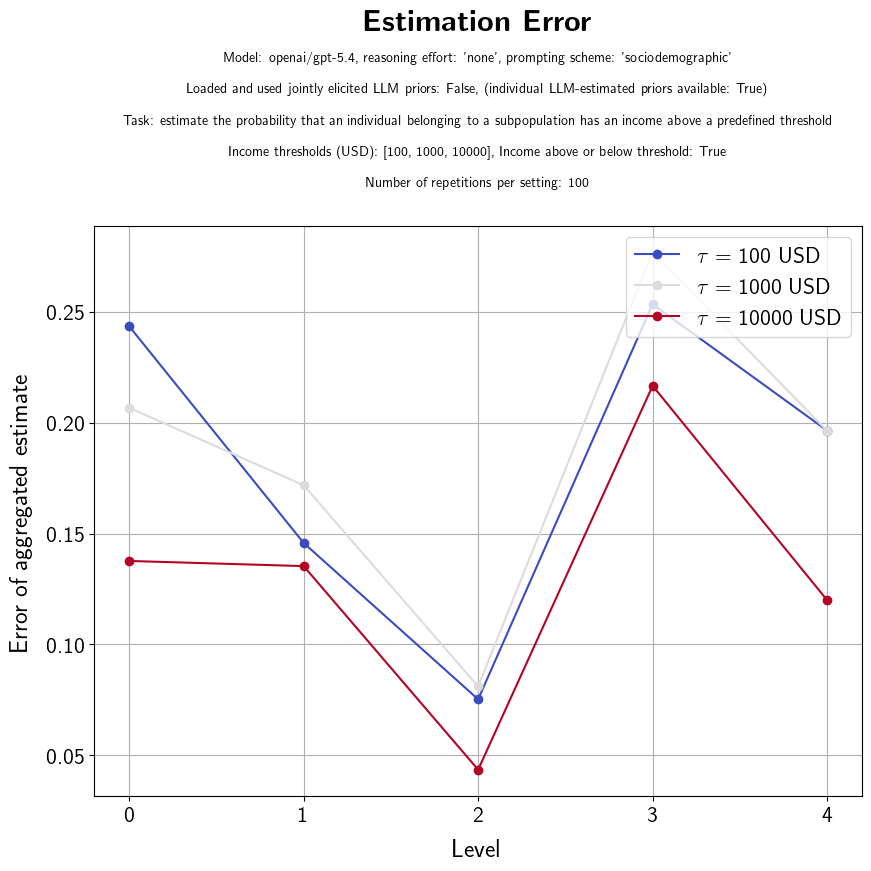

In [9]:
# Plot size
plt.figure(figsize=(9, 9))

# Colormap
entries = results["refinement_results"]
cmap = plt.get_cmap("coolwarm")
n = len(entries)

# Plot all results in the list
all_x = set()
for i, entry in enumerate(entries):
    x = []
    y = []

    # Collect data from dict
    for level, result in sorted(entry["refinement_results"].items(), key=lambda t: int(t[0])):
        level_int = int(level)
        all_x.add(level_int)

        # Add to list
        x.append(level_int)
        y.append(result["aggregated_error"])

    # Plot
    color = cmap(i / max(n - 1, 1))  # avoid div-by-zero if n == 1
    plt.plot(x, y, marker="o", color=color,
             label=r"$\tau = " + f"{entry['income_threshold']}$ USD")

# Formatting
plt.title(title)
plt.xlabel("Level", labelpad=10)
plt.ylabel("Error of aggregated estimate", labelpad=10)
x_ticks = list(range(min(all_x), max(all_x) + 1))
plt.xticks(x_ticks)
plt.legend(loc="upper right")
plt.grid()
plt.tight_layout()

# Add prior to plot name
prior_usage = "llm_prior" if load_joint_llm_priors else "gt_prior"

# Save plot
plot_subdir = plot_dir / prior_usage
plot_subdir.mkdir(parents=True, exist_ok=True)
plt.savefig(plot_subdir / f"threshold_{experiment_name}.png", dpi=300)
plt.savefig(plot_subdir / f"threshold_{experiment_name}.pdf")

# Show plot
plt.show()